In [4]:
import sys

sys.path.append('../src')
from preprocessor import run_preprocessing

X_train, X_test, y_train, y_test, feature_cols = run_preprocessing(
    data_path='../data/cleaned.csv',
    mode='binary',
    sample_frac=0.3,   # use 30% during dev, change to 1.0 for final run
    test_size=0.2
)

Loading cleaned dataset from ../data/cleaned.csv...
Loaded: (2572640, 79)
Sampled 30% → 771,792 rows
Dropped 8 low-variance columns

Features: 70
Label column: binary_label
Class distribution:
binary_label
0    643919
1    127873
Train: (617433, 70) | Test: (154359, 70)
Train label distribution:
binary_label
0    515135
1    102298


In [5]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',  # handles 83/17 imbalance automatically
    random_state=42,
    n_jobs=-1                 # uses all CPU cores
)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [6]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    scale_pos_weight=214858/42406,  # ratio of benign/attack from your output
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)
xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'



=== Random Forest ===
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00    128784
      ATTACK       1.00      0.99      1.00     25575

    accuracy                           1.00    154359
   macro avg       1.00      1.00      1.00    154359
weighted avg       1.00      1.00      1.00    154359



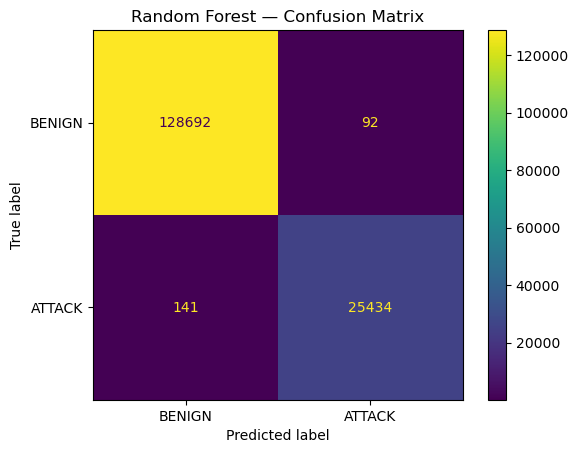


=== XGBoost ===
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00    128784
      ATTACK       0.99      1.00      1.00     25575

    accuracy                           1.00    154359
   macro avg       1.00      1.00      1.00    154359
weighted avg       1.00      1.00      1.00    154359



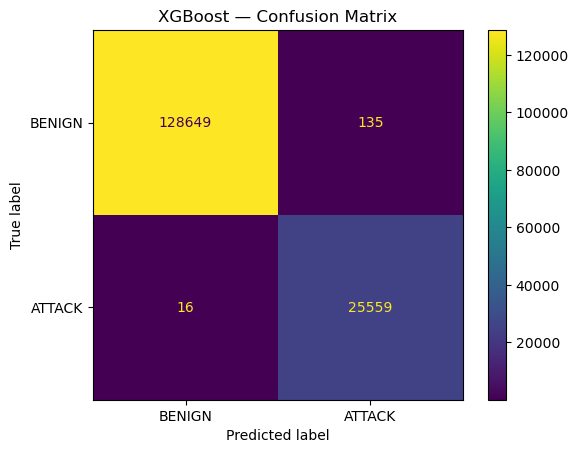

In [7]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

for name, model in [('Random Forest', rf), ('XGBoost', xgb)]:
    y_pred = model.predict(X_test)
    print(f'\n=== {name} ===')
    print(classification_report(y_test, y_pred,
          target_names=['BENIGN', 'ATTACK']))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['BENIGN', 'ATTACK'])
    disp.plot()
    plt.title(f'{name} — Confusion Matrix')
    plt.savefig(f'../notebooks/{name.lower().replace(" ","_")}_cm.png', dpi=150)
    plt.show()

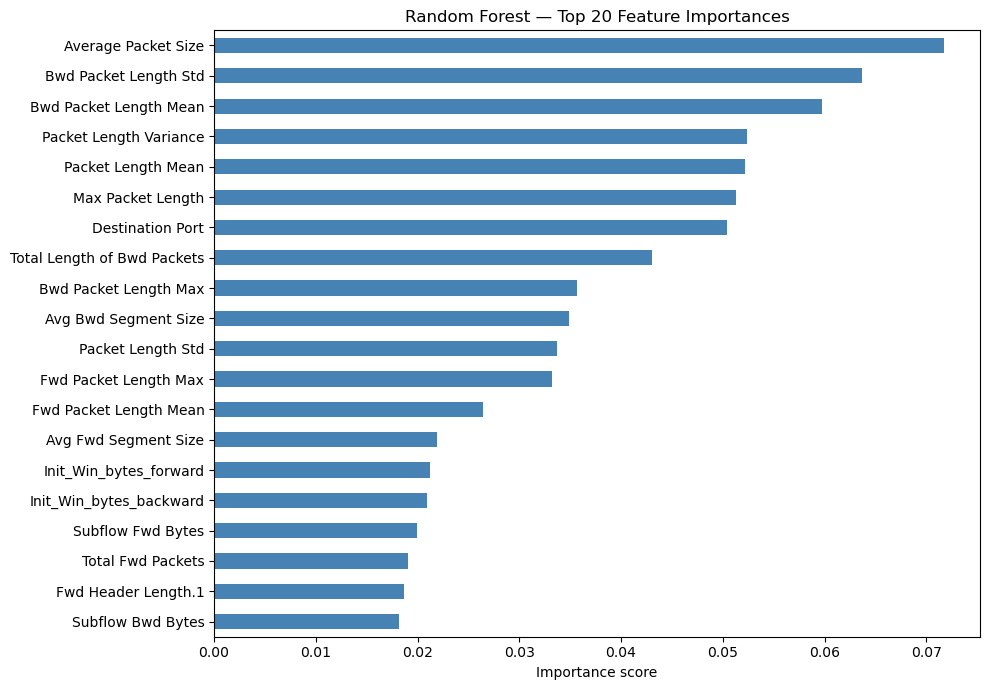

Average Packet Size            0.071684
Bwd Packet Length Std          0.063663
Bwd Packet Length Mean         0.059752
Packet Length Variance         0.052391
Packet Length Mean             0.052149
Max Packet Length              0.051319
Destination Port               0.050385
Total Length of Bwd Packets    0.043045
Bwd Packet Length Max          0.035691
Avg Bwd Segment Size           0.034905
Packet Length Std              0.033699
Fwd Packet Length Max          0.033220
Fwd Packet Length Mean         0.026446
Avg Fwd Segment Size           0.021857
Init_Win_bytes_forward         0.021175
Init_Win_bytes_backward        0.020963
Subflow Fwd Bytes              0.019899
Total Fwd Packets              0.019062
Fwd Header Length.1            0.018639
Subflow Bwd Bytes              0.018170


In [9]:
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(rf.feature_importances_, index=feature_cols)
top20 = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 7))
top20.plot(kind='barh', color='steelblue')
plt.gca().invert_yaxis()
plt.title('Random Forest — Top 20 Feature Importances')
plt.xlabel('Importance score')
plt.tight_layout()
plt.savefig('../notebooks/feature_importances.png', dpi=150)
plt.show()

print(top20.to_string())

In [8]:
import joblib, json

# Save model
joblib.dump(rf, '../models/rf_model.pkl')

# Save feature list — critical for live inference
json.dump(feature_cols, open('../models/feature_list.json', 'w'), indent=2)

# Save metrics
from sklearn.metrics import f1_score, precision_score, recall_score
y_pred = rf.predict(X_test)
metrics = {
    'model'    : 'RandomForest',
    'f1'       : f1_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred),
    'recall'   : recall_score(y_test, y_pred),
    'n_estimators': 100
}
json.dump(metrics, open('../models/metrics.json', 'w'), indent=2)
print('Model saved.')

Model saved.
